In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df1 = pd.read_csv("Bangalore.csv")
df2 = pd.read_csv("Chennai.csv")
df3 = pd.read_csv("Delhi.csv")
df4 = pd.read_csv("Hyderabad.csv")
df5 = pd.read_csv("Kolkata.csv")
df6 = pd.read_csv("Mumbai.csv")




In [3]:
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

In [4]:

print(df.head())
print(df.info())
print(df.describe())

      Price  Area                         Location  No. of Bedrooms  Resale  \
0  30000000  3340                 JP Nagar Phase 1                4       0   
1   7888000  1045       Dasarahalli on Tumkur Road                2       0   
2   4866000  1179  Kannur on Thanisandra Main Road                2       0   
3   8358000  1675                     Doddanekundi                3       0   
4   6845000  1670                          Kengeri                3       0   

   MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  \
0                 1          1             1                  1             1   
1                 0          1             1                  1             1   
2                 0          1             1                  1             1   
3                 0          0             0                  0             0   
4                 1          1             1                  1             1   

   ...  LiftAvailable  BED  VaastuComp

In [5]:
# Missing values
print(df.isnull().sum())


Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Stadium                0


In [6]:
df = df.dropna()

In [7]:
# Remove top 1% extreme prices
df = df[df['Price'] < df['Price'].quantile(0.99)]

# Remove unrealistic area values
df = df[df['Area'] < df['Area'].quantile(0.99)]

In [8]:
df = pd.get_dummies(df, drop_first=True)

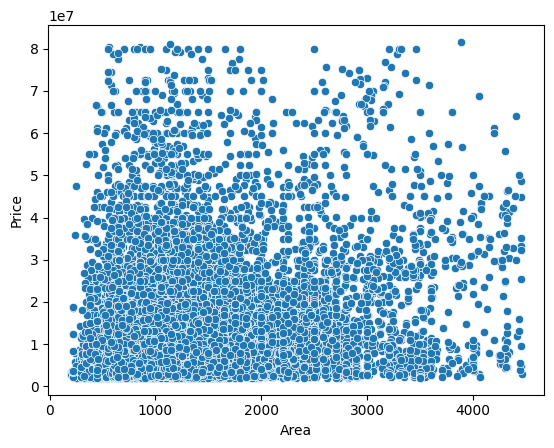

In [9]:
sns.scatterplot(x='Area', y='Price', data=df)
plt.show()

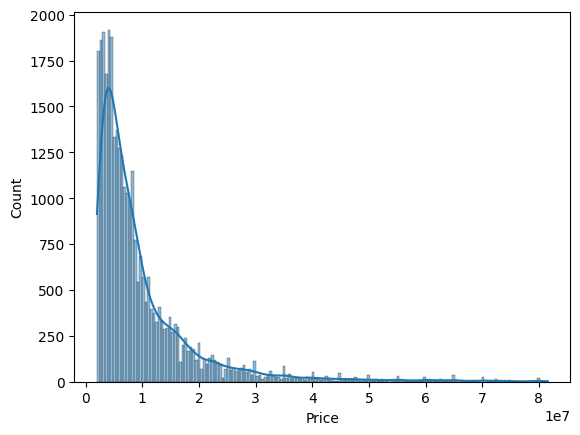

In [10]:
# Distribution
sns.histplot(df['Price'], kde=True)
plt.show()

In [11]:
X = df[['Area']]
y = df['Price']



In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [13]:
linear = LinearRegression()
linear.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
linear_pred = linear.predict(X_test)

print("Linear R2:", r2_score(y_test, linear_pred))

Linear R2: 0.08240864287284422


In [15]:
# Drop non-numeric columns if needed
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Price', axis=1)
y = df['Price']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [17]:
multi_linear = LinearRegression()
multi_linear.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred_mlr = multi_linear.predict(X_test)

print("MLR R2:", r2_score(y_test, y_pred_mlr))

MLR R2: 0.2680325675699847


PCA with Multi linear

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [20]:
pca = PCA(n_components=5)  
X_pca = pca.fit_transform(X_scaled)



In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [22]:
mlr_pca = LinearRegression()
mlr_pca.fit(X_train, y_train)

y_pred_pca = mlr_pca.predict(X_test)

print("PCA + MLR R2:", r2_score(y_test, y_pred_pca))

PCA + MLR R2: 0.08655449550240302


Ridge & Lasso

In [23]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso R2: 0.08655449587465869


In [24]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.08655478373521253


In [25]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

print("SVR R2:", r2_score(y_test, y_pred_svr))

SVR R2: -0.11021271881182959


Decision Tree

In [26]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: -0.10928823851055691


Random Forest

In [34]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [35]:
print('R2 score', r2_score(y_test, y_pred_rf))

R2 score 0.24247256146128648


GridSearch CV

In [28]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 50}


RandomizedSearchCV

In [29]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30]
}

random = RandomizedSearchCV(RandomForestRegressor(), param_dist, n_iter=5, cv=3)
random.fit(X_train, y_train)

print("Best Params:", random.best_params_)

Best Params: {'n_estimators': 200, 'max_depth': 10}


In [36]:
results = {
    "linear": r2_score(y_test, linear_pred),
    "MLR": r2_score(y_test, y_pred_mlr),
    "PCA+MLR": r2_score(y_test, y_pred_pca),
    "Lasso": r2_score(y_test, y_pred_lasso),
    "Ridge": r2_score(y_test, y_pred_ridge),
    "SVR": r2_score(y_test, y_pred_svr),
    "Decision Tree": r2_score(y_test, y_pred_dt),
    "Random Forest": r2_score(y_test, y_pred_rf)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

linear: 0.0824
MLR: 0.2680
PCA+MLR: 0.0866
Lasso: 0.0866
Ridge: 0.0866
SVR: -0.1102
Decision Tree: -0.1093
Random Forest: 0.2425
